## SVM, DT EDA

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


seed = 1234
np.random.seed(seed)

In [6]:
data = pd.read_csv("Invistico_Airline.csv")

y_column = ['satisfaction']
numeric_columns = ['Age', 'Flight Distance',
                   'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_columns = ['Seat comfort', 'Departure/Arrival time convenient',
                   'Food and drink', 'Gate location',
                   'Inflight wifi service', 'Inflight entertainment',
                   'Online support', 'Ease of Online booking',
                   'On-board service', 'Leg room service',
                   'Baggage handling', 'Checkin service',
                   'Cleanliness', 'Online boarding']
category_columns = ['Gender', 'Customer Type',
                    'Type of Travel', 'Class']

In [7]:

# drop NA
data_cleaned = data.dropna()

# remove
time_limit = 300
data_cleaned = data_cleaned[(data_cleaned['Arrival Delay in Minutes'] < time_limit) &
                            (data_cleaned['Departure Delay in Minutes'] < time_limit)]

# encoding
data_cate_encoded = pd.get_dummies(data_cleaned[category_columns], drop_first=True)
data_target_encoded = pd.get_dummies(data_cleaned[y_column], drop_first=True)




In [8]:
data_combined = pd.concat([data_target_encoded,
                           data_cleaned[numeric_columns + ordinal_columns],
                           data_cate_encoded], axis=1)

y_column = ['satisfaction_satisfied']
ext_ordinal_columns = ['Inflight entertainment', 'Ease of Online booking',
                       'Online support', 'On-board service',
                       'Online boarding', 'Leg room service',
                       'Checkin service', 'Baggage handling',
                       'Cleanliness', 'Seat comfort',
                       'Inflight wifi service', 'Food and drink']
ext_category_columns = ['Customer Type_disloyal Customer', 'Class_Eco',
                        'Gender_Male']

ext_data_combined = data_combined[y_column + ext_ordinal_columns]



In [9]:
from sklearn.model_selection import train_test_split

X = ext_data_combined.drop(y_column, axis=1)
y = ext_data_combined[y_column]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [11]:
y_tain_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

acc_train = accuracy_score(y_train, y_tain_pred_lr)
acc_test = accuracy_score(y_test, y_test_pred_lr)

print(f" ACC : {acc_train*100:.1f} %")
print(f" ACC : {acc_test*100:.1f} %")

 ACC : 80.6 %
 ACC : 80.4 %


Text(0.5, 1.0, 'Feature Importance')

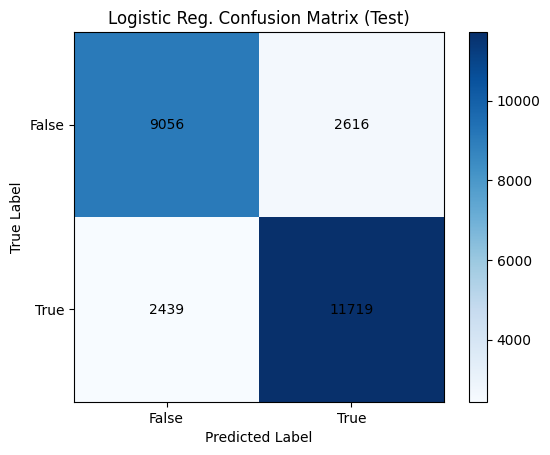

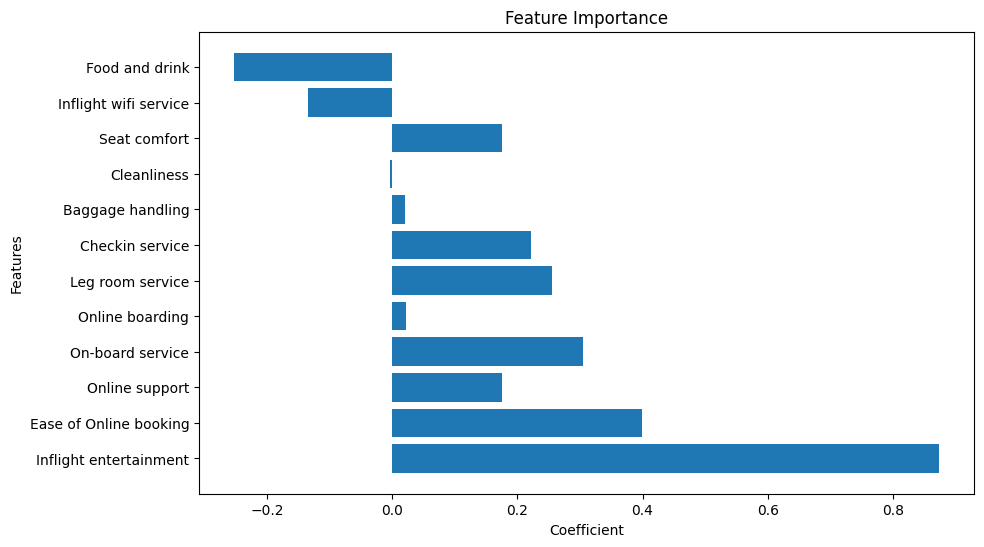

In [12]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_test_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.imshow(cm_test_lr, interpolation='nearest', cmap="Blues")
plt.title("Logistic Reg. Confusion Matrix (Test)")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))

plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


for i in range(cm_test_lr.shape[0]) :
  for j in range(cm_test_lr.shape[1]) :
    plt.text(j, i, cm_test_lr[i, j], ha="center", va="center",
             color="black")

plt.figure(figsize=(10, 6))
plt.barh(X_train.columns, lr.coef_.flatten())
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Feature Importance")



In [13]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=0.1)

- SVM time complexity
>  $ O( n^{2}_{sample} x n_{feat}) $ ~ $  O(n^{3}_{sample} x n_{feat})  $

In [14]:
svm.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=0.1)

In [15]:
y_train_pred_svm = svm.predict(X_train)
y_test_pred_svm = svm.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred_svm)
acc_test = accuracy_score(y_test, y_test_pred_svm)

print(f' SVM Acc : {acc_train*100:0.1f} %')
print(f' SVM Acc : {acc_test*100:0.1f} %')


 SVM Acc : 90.6 %
 SVM Acc : 90.5 %


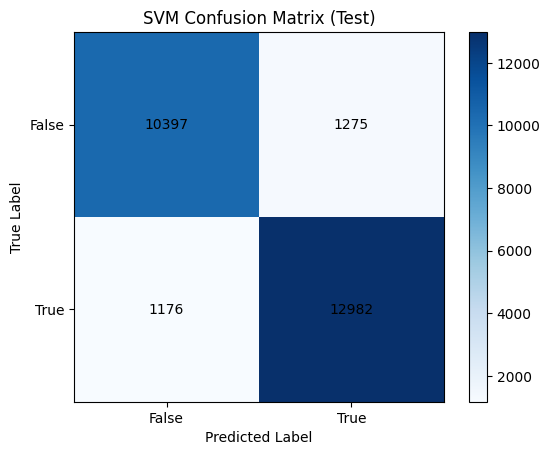

In [17]:
cm_test_svm = confusion_matrix(y_test, y_test_pred_svm)


plt.imshow(cm_test_svm, interpolation='nearest', cmap='Blues')
plt.title("SVM Confusion Matrix (Test)")
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_test_svm.shape[0]):
    for j in range(cm_test_svm.shape[1]):
        plt.text(j, i, cm_test_svm[i, j], ha="center", va="center", color="black")




## rating scale

- Precision : When the predicted positive result is actually
positive
  -  $ \frac{TP}{TP + FP} $

- Recall : It meass to how well the positives were found among the actual positives
  -  $ \frac{TP}{TP + FN} $

- F1 : Harmonic average of precision and recall

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

lr_precision = precision_score(y_test, y_test_pred_lr)
lr_recall = recall_score(y_test, y_test_pred_lr)
lr_f1 = f1_score(y_test, y_test_pred_lr)

print(f'Logistic P, R, F1 : {lr_precision:.2f} / {lr_recall:.2f} / {lr_f1:.2f}')


svm_precision = precision_score(y_test, y_test_pred_svm)
svm_recall = recall_score(y_test, y_test_pred_svm)
svm_f1 = f1_score(y_test, y_test_pred_svm)
print(f'SVM P, R, F1 : {svm_precision:.2f} / {svm_recall:.2f} / {svm_f1:.2f}')




Logistic P, R, F1 : 0.82 / 0.83 / 0.82
SVM P, R, F1 : 0.91 / 0.92 / 0.91


In [19]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',
                            max_depth=5,
                            min_samples_split=5)


In [20]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)

Text(0.5, 1.0, 'Plot of Decison Tree')

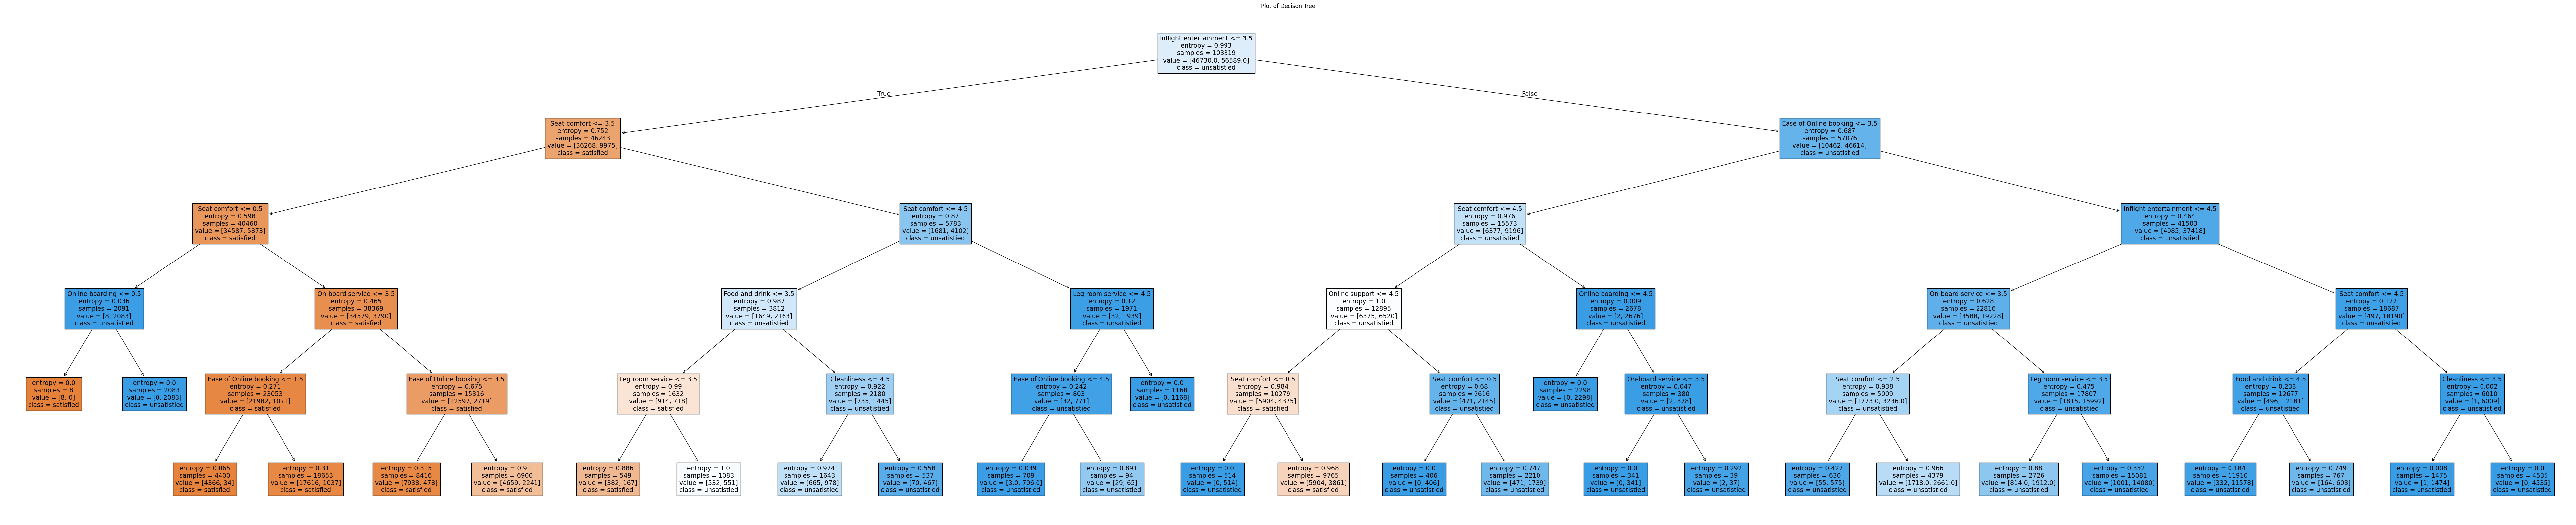

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(100, 20))
plot_tree(dt, filled=True,
          feature_names = ext_ordinal_columns + ext_category_columns,
          class_names=['satisfied', 'unsatistied'])
plt.title("Plot of Decison Tree")

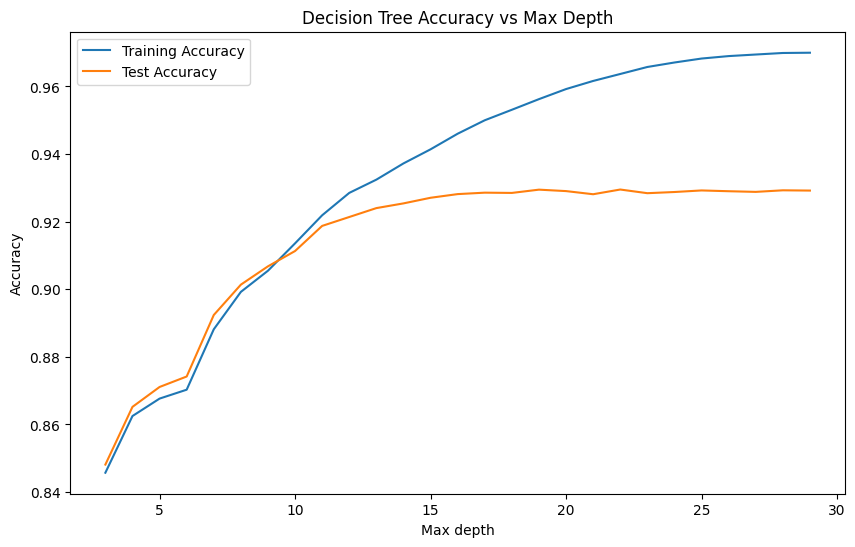

In [22]:
max_depths = range(3, 30)

train_accuracies = []
test_accuracies = []

for depth in max_depths:
  model = DecisionTreeClassifier(criterion='entropy',
                                 max_depth = depth,
                                 min_samples_split=5)

  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  train_acc = accuracy_score(y_train, y_train_pred)
  train_accuracies.append(train_acc)

  y_test_pred = model.predict(X_test)
  test_acc = accuracy_score(y_test, y_test_pred)
  test_accuracies.append(test_acc)

plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_accuracies, label='Training Accuracy')
plt.plot(max_depths, test_accuracies, label='Test Accuracy')
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.legend()

In [24]:
max_acc = max(test_accuracies)
best_depth = max_depths[test_accuracies.index(max_acc)]
print('Best Depth : ', best_depth)

df = DecisionTreeClassifier(criterion="entropy",
                            max_depth=best_depth,
                            min_samples_split=5)

Best Depth :  22


In [25]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)

In [27]:
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred_dt)
acc_test = accuracy_score(y_test, y_test_pred_dt)

print(f' Train ACC : {acc_train*100:.1F}%')
print(f' Test ACC : {acc_test*100:.1F}%')

 Train ACC : 86.8%
 Test ACC : 87.1%


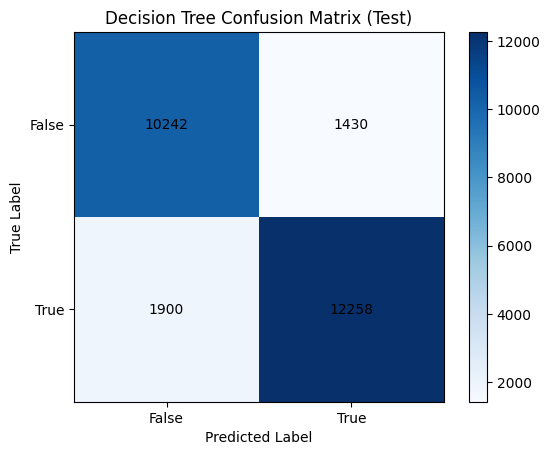

In [28]:
cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)

plt.imshow(cm_test_dt, interpolation='nearest', cmap='Blues')
plt.title("Decision Tree Confusion Matrix (Test)")
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, np.unique(y_test))
plt.yticks(tick_marks, np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm_test_dt.shape[0]):
    for j in range(cm_test_dt.shape[1]):
        plt.text(j, i, cm_test_dt[i, j], ha="center", va="center", color="black")

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score



logistic_precision = precision_score(y_test, y_test_pred_lr)
logistic_recall = recall_score(y_test, y_test_pred_lr)
logistic_f1 = f1_score(y_test, y_test_pred_lr)
print(f'Logistic P,R,F1 : {logistic_precision:.2f} / {logistic_recall:.2f} / {logistic_f1:.2f}')


svm_precision = precision_score(y_test, y_test_pred_svm)
svm_recall = recall_score(y_test, y_test_pred_svm)
svm_f1 = f1_score(y_test, y_test_pred_svm)
print(f'SVM P,R,F1 : {svm_precision:.2f} / {svm_recall:.2f} / {svm_f1:.2f}')


dt_precision = precision_score(y_test, y_test_pred_dt)
dt_recall = recall_score(y_test, y_test_pred_dt)
dt_f1 = f1_score(y_test, y_test_pred_dt)
print(f'DT P,R,F1 : {dt_precision:.2f} / {dt_recall:.2f} / {dt_f1:.2f}')

Logistic P,R,F1 : 0.82 / 0.83 / 0.82
SVM P,R,F1 : 0.91 / 0.92 / 0.91
DT P,R,F1 : 0.90 / 0.87 / 0.88
